## TO BE deleted

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [ ]:
from anomaly_detection.utils.load_sam_data import load_dataset

dataset = load_dataset("FJ")
dataset = np.array(dataset)

..\data\FJ\FI01X1\FI01X1_ch


In [ ]:
from anomaly_detection.utils.autoencoders import prepocess_data

torch_df = prepocess_data(dataset)

# About
- stable model works with MSE loss, uses Adam optimizer
- reconstructions are not yet ideal but the autoencoder shows some patterns 
- problem is in teeth like patterns in reconstruction see plots int the end 
- lots of times model learns couple of representations and sticks to them
    - this results still in fine results but shitty reconstructions but is caused mainly by the MSE loss 
    - Main goal of the next model is to fix this and get proper reconstructions

In [5]:
# EXPERIMENTS
pt = torch_df[123]
pt = pt.reshape(1, 1, len(pt))

import torch.nn as nn

encoder = nn.Sequential(
        nn.Conv1d(1, 1, kernel_size=2),  
        nn.BatchNorm1d(1),
        nn.ReLU(),
        
        nn.Conv1d(1, 1, kernel_size=3, stride=2),  
        nn.BatchNorm1d(1),
        nn.ReLU(),

        
        nn.Conv1d(1, 3, kernel_size=3, stride=2), 
        nn.BatchNorm1d(3),
        nn.Sigmoid()
)

decoder = nn.Sequential(
        nn.ConvTranspose1d(3, 1, kernel_size=2),  
        nn.BatchNorm1d(1),
        nn.ReLU(),
        
        nn.ConvTranspose1d(1, 1, kernel_size=2, stride=2),  
        nn.BatchNorm1d(1),
        nn.ReLU(),
        
        nn.ConvTranspose1d(1, 1, kernel_size=2, stride=2),
        nn.BatchNorm1d(1),
        nn.Sigmoid()
)

pt = encoder(pt)
print(pt.shape)
decoder(pt).shape

torch.Size([1, 3, 23])


torch.Size([1, 1, 96])

In [6]:
import torch.nn as nn

# first model
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 1, kernel_size=2),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            
            nn.Conv1d(1, 1, kernel_size=6, stride=2, padding=1),  
            nn.BatchNorm1d(1),
            nn.ReLU(),

            
            nn.Conv1d(1, 3, kernel_size=6, stride=2, padding=1), 
            nn.BatchNorm1d(3),
            nn.Sigmoid()
            )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(3, 1, kernel_size=4, stride=2),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            nn.ConvTranspose1d(1, 1, kernel_size=6, stride=2),
            nn.BatchNorm1d(1),
            nn.Sigmoid()
            )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
from torch.utils.data import DataLoader
from anomaly_detection.utils.autoencoders import HistDataset

batch_size = 32
torch_small_df = HistDataset(torch_df)
dataloader = DataLoader(torch_small_df, batch_size=batch_size, shuffle=False)

In [8]:
ae_conv = Autoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=ae_conv.parameters(), lr=0.002)

In [ ]:
from anomaly_detection.utils.autoencoders import train_ae

ae_conv.train()
losses, ae_conv = train_ae(n_epochs=40, dataloader=dataloader, model=ae_conv, optimizer=optimizer, criterion=criterion)

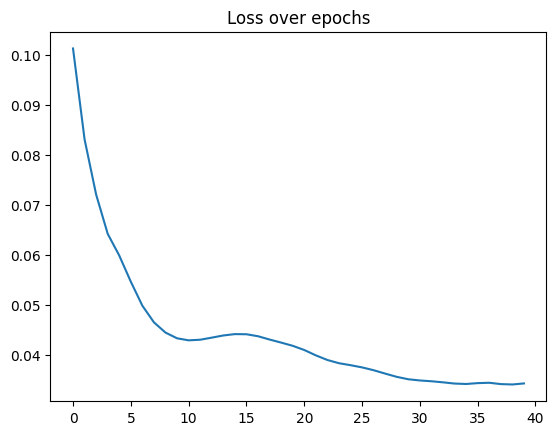

In [10]:
plt.title('Loss over epochs')
plt.plot(range(len(losses)), losses)

c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([1, 96])) that is different to the input size (torch.Size([1, 1, 96])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


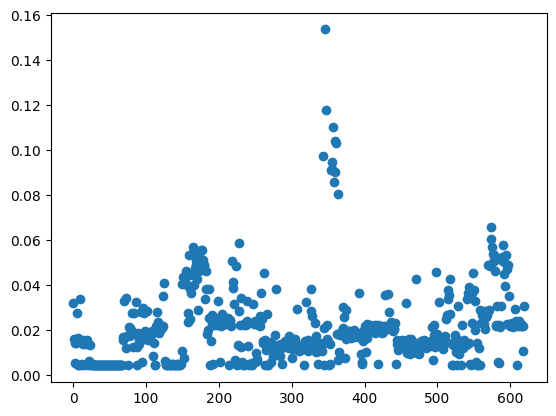

In [ ]:
#ae_conv.eval()
from anomaly_detection.utils.autoencoders import eval_and_plot_score

score = eval_and_plot_score(model=ae_conv, dataloader=dataloader, criterion=criterion)

In [12]:
score_dict = {idx : s for idx, s in enumerate(score)}
indexes_sorted_by_score = sorted(score_dict, key=lambda x: score_dict[x], reverse=True)

print("highest scores", indexes_sorted_by_score[:10] )
print("lowest scores", indexes_sorted_by_score[-3:])

highest scores [346, 347, 357, 359, 361, 343, 356, 355, 354, 360]
lowest scores [146, 67, 66]


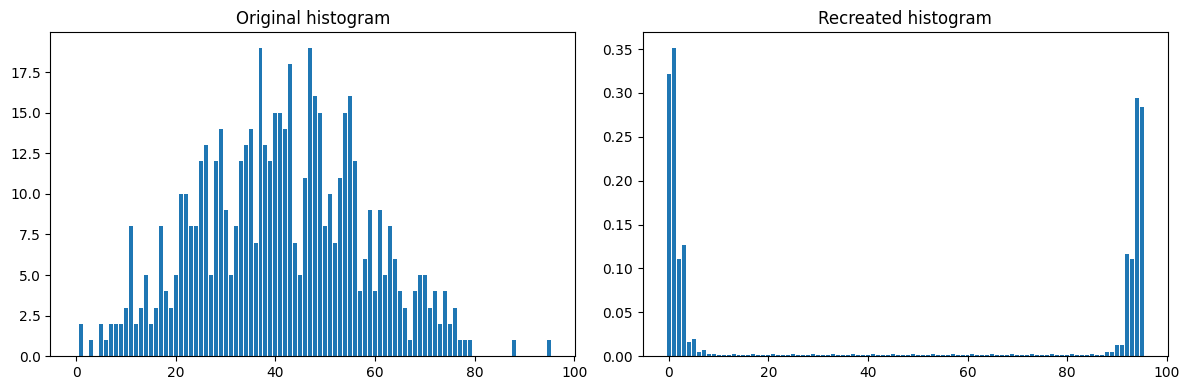

In [ ]:
idx = 6
ae_conv.eval()

pred = ae_conv(torch_small_df[idx].unsqueeze(0))
pred = pred.detach().numpy().squeeze()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), dataset[idx])
axes[0].set_title("Original histogram")

axes[1].bar(range(len(pred)), pred)
axes[1].set_title("Recreated histogram")

plt.tight_layout()
plt.show()

In [14]:
#torch.save(ae_conv.state_dict(), 'ae_1st.pth')